# B) Fuel comparison by canton


In [68]:
import json
import urllib.request
from pathlib import Path

import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.collections import PatchCollection
from matplotlib.lines import Line2D
from matplotlib.patches import Polygon, Wedge
from matplotlib.ticker import FuncFormatter

from preparation import PreparSwissVehicle, canton_bfs, canton_short


with open("./shared_configs.json", encoding="utf-8") as f:
    cfg = json.load(f)

output_dir = Path(cfg["output_dir"])
figure_size = cfg["figure_size"]
colors = cfg["fuel_category_colors"]
saving_cfg = cfg["saving_config"]
data_source_cfg = cfg["data_source"]
title_cfg = cfg["title_style"]
subtitle_cfg = cfg["subtitle_style"]

MAP_GRADIENT_LOW = cfg["b_fuel_canton"]["map_gradient_low"]
DIV_LABEL_COLORS = cfg["b_fuel_canton"]["diverging_axis_label_colors"]

prep = PreparSwissVehicle()
category_order = prep.category_order
latest_year = prep.latest_year

bar_df = prep.current_year_pivot().sort_values("BEV", ascending=False)
bar_df


FuelCategory,BEV,Petrol,Diesel,Hybrid,Other
Canton,,,,,
Zurich,49234,421685,176558,95651,3621
Vaud,24498,257960,85310,67537,1358
Bern,23784,331567,140926,51019,1381
Aargau,22514,252502,108525,47115,1091
St. Gallen,15240,170276,84985,28799,678
Lucerne,12781,132086,59663,24754,468
Valais,10603,149325,59836,23656,343
Fribourg,10534,124644,42672,27309,269
Thurgau,9881,112982,48477,18072,421


## MAP 

In [69]:

map_df = bar_df.reset_index().copy()
map_df["total"] = map_df[category_order].sum(axis=1)
map_df["bfs"] = map_df["Canton"].map(canton_bfs)


# Fetch canton geometries once
canton_geoms = {}
for _, row in map_df.dropna(subset=["bfs"]).iterrows():
    bfs = int(row["bfs"])
    url = (
        "https://api3.geo.admin.ch/rest/services/api/MapServer/"
        f"ch.swisstopo.swissboundaries3d-kanton-flaeche.fill/{bfs}"
        "?geometryFormat=geojson&sr=4326"
    )
    response = urllib.request.urlopen(url, timeout=30)
    payload = json.loads(response.read().decode("utf-8"))
    canton_geoms[bfs] = payload["feature"]["geometry"]


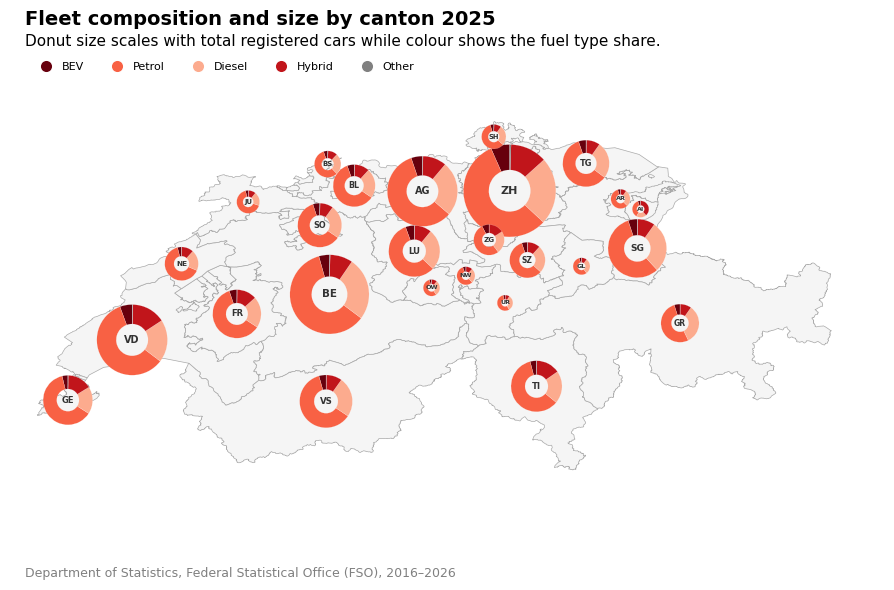

Saved: ..\docs\graphic_own\vis_b_map.png


In [70]:

fuel_cats = category_order

# ── Helpers ───────────────────────────────────────────────────────────────────
def extract_outer_rings(geometry):
    coords = geometry["coordinates"]
    if geometry["type"] == "Polygon":
        return [coords[0]]
    if geometry["type"] == "MultiPolygon":
        return [polygon[0] for polygon in coords]
    return []

def polygon_centroid(ring):
    pts = np.asarray(ring)
    x, y = pts[:, 0], pts[:, 1]
    cross = x * np.roll(y, -1) - np.roll(x, -1) * y
    area = 0.5 * np.sum(cross)
    if abs(area) < 1e-12:
        return x.mean(), y.mean()
    cx = np.sum((x + np.roll(x, -1)) * cross) / (6 * area)
    cy = np.sum((y + np.roll(y, -1)) * cross) / (6 * area)
    return cx, cy

def polygon_area(ring):
    pts = np.asarray(ring)
    x, y = pts[:, 0], pts[:, 1]
    return abs(0.5 * np.sum(x * np.roll(y, -1) - y * np.roll(x, -1)))

def draw_donut(ax, center, r, values, slice_colors):
    total = np.sum(values)
    if total <= 0:
        return
    start = 90
    for value, color in zip(values, slice_colors):
        if value <= 0:
            continue
        angle = 360 * value / total
        wedge = Wedge(
            center=center, r=r, theta1=start, theta2=start + angle,
            width=r * 0.55, facecolor=color, edgecolor="white", linewidth=0.1, zorder=3,
        )
        ax.add_patch(wedge)
        start += angle


# ── Radius scaling ────────────────────────────────────────────────────────────
LON_SCALE = np.cos(np.radians(47))
MAX_TOTAL = map_df["total"].max()
MAX_R = 0.18

MIN_R_FOR_LABEL = 0.02
FONT_MIN, FONT_MAX = 4.5, 8.0
R_FONT_MIN, R_FONT_MAX = MIN_R_FOR_LABEL, MAX_R / LON_SCALE * 0.45

slice_colors = [colors[c] for c in fuel_cats]

# ── Figure ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=figure_size)
outline_patches = []

# ── Per-canton center nudges (lon, lat) ───────────────────────────────────────
NUDGE = {
    "St. Gallen":        (+0.09, -0.17),
    "Schwyz":            (0.0, -0.045),
    "Basel-Landschaft":  (0.12, 0.0),
    "Vaud":              (-0.15, 0.0),
    "Appenzell Ausserrhoden": (-0.08, 0.0),
    "Zug":               (0.0, -0.025),
    "Solothurn":         (-0.08, -0.08),
    "Basel-Landschaft":  (0.06, -0.01),
}

for _, row in map_df.dropna(subset=["bfs"]).iterrows():
    bfs = int(row["bfs"])
    geom = canton_geoms[bfs]
    rings = extract_outer_rings(geom)
    if not rings:
        continue

    values = row[fuel_cats].fillna(0).astype(float).to_numpy()
    total = row["total"]
    r = MAX_R * np.sqrt(total / MAX_TOTAL) / LON_SCALE

    largest = max(rings, key=polygon_area)
    cx, cy = polygon_centroid(largest)

    dx, dy = NUDGE.get(row["Canton"], (0.0, 0.0))
    cx += dx
    cy += dy

    draw_donut(ax, center=(cx, cy), r=r, values=values, slice_colors=slice_colors)

    hole_r = r * 0.45
    if hole_r >= MIN_R_FOR_LABEL:
        t = np.clip((hole_r - R_FONT_MIN) / (R_FONT_MAX - R_FONT_MIN), 0, 1)
        fontsize = FONT_MIN + t * (FONT_MAX - FONT_MIN)
        label = canton_short.get(row["Canton"], row["Canton"])
        ax.text(cx, cy, label, ha="center", va="center",
                fontsize=fontsize, color="#333333", fontweight="bold", zorder=5)

    for ring in rings:
        outline_patches.append(Polygon(ring, closed=True))

outline_col = PatchCollection(
    outline_patches, facecolor="#f5f5f5", edgecolor="#aaaaaa", linewidth=0.5, zorder=1
)
ax.add_collection(outline_col)

ax.set_xlim(5.8, 10.8)
ax.set_ylim(45.7, 47.9)
ax.set_aspect("equal")
ax.set_axis_off()

fig.text(s=f"Fleet composition and size by canton {latest_year}", **title_cfg)
fig.text(s="Donut size scales with total registered cars while colour shows the fuel type share.", **subtitle_cfg)

legend_handles = [
    Line2D([0], [0], marker="o", color="none", markerfacecolor=colors[cat],
           markeredgecolor="white", markersize=9, label=cat)
    for cat in fuel_cats
]
fig.legend(handles=legend_handles,
           loc="upper left",
           bbox_to_anchor=(0.04, 0.90),
           bbox_transform=fig.transFigure,
           ncol=len(fuel_cats), frameon=False,
           labelspacing=0.2, handletextpad=0.4,
           fontsize=8)

fig.text(**data_source_cfg)

plt.subplots_adjust(left=0.025, **cfg["plot_space"])

map_path = output_dir / "vis_b_map.png"
plt.savefig(map_path, **saving_cfg)
plt.show()
print(f"Saved: {map_path}")


## Stacked Barcharts 

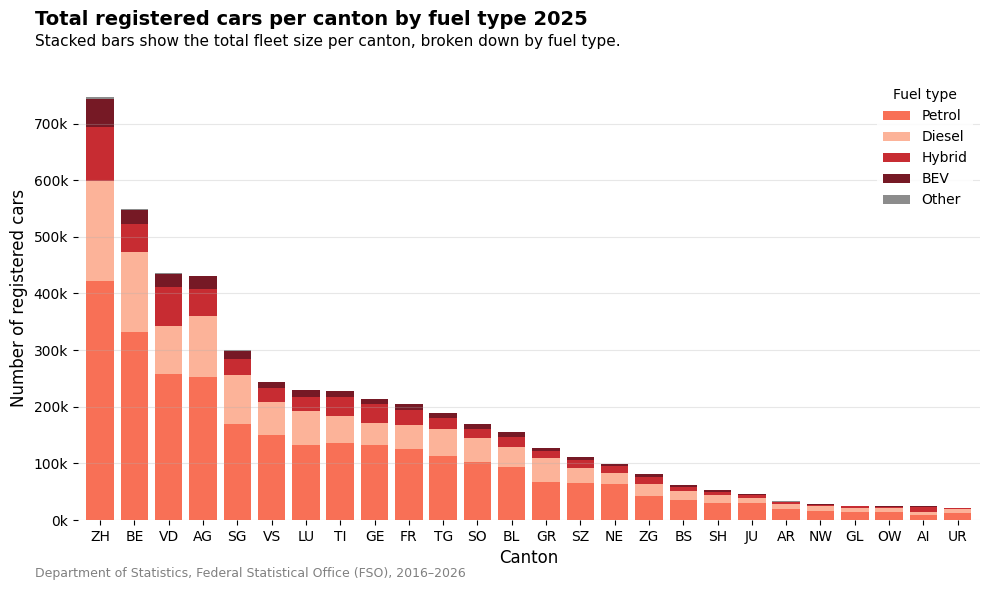

Saved: ..\docs\graphic_own\vis_b_bar_0.png


In [71]:
plot_order = ["Petrol", "Diesel", "Hybrid", "BEV", "Other"]
plot_df = bar_df[plot_order]
plot_df = bar_df[plot_order]
plot_df = plot_df.loc[plot_df.sum(axis=1).sort_values(ascending=False).index]


fig, ax = plt.subplots(figsize=figure_size)
plot_df.plot(
    kind="bar",
    stacked=True,
    ax=ax,
    width=0.8,
    color=[colors[c] for c in plot_order],
    alpha=0.9,
)

for spine in ax.spines.values():
    spine.set_visible(False)

ax.grid(alpha=0.3, axis="y")
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x/1000:,.0f}k".replace(",", "'")))
ax.set_xlabel("Canton", fontsize=12)
ax.set_ylabel("Number of registered cars", fontsize=12)

fig.text(s=f"Total registered cars per canton by fuel type {latest_year}", **title_cfg)
fig.text(s="Stacked bars show the total fleet size per canton, broken down by fuel type.", **subtitle_cfg)

ax.set_xticklabels([canton_short.get(c, c) for c in plot_df.index], rotation=0)

ax.legend(title="Fuel type", loc="upper right", bbox_to_anchor=(1.0, 1.0),
          framealpha=0.85, edgecolor="none")

fig.text(**data_source_cfg)

plt.tight_layout()
plt.subplots_adjust(**cfg["plot_space"])

bar_path = output_dir / "vis_b_bar_0.png"
plt.savefig(bar_path, **saving_cfg)
plt.show()

print(f"Saved: {bar_path}")


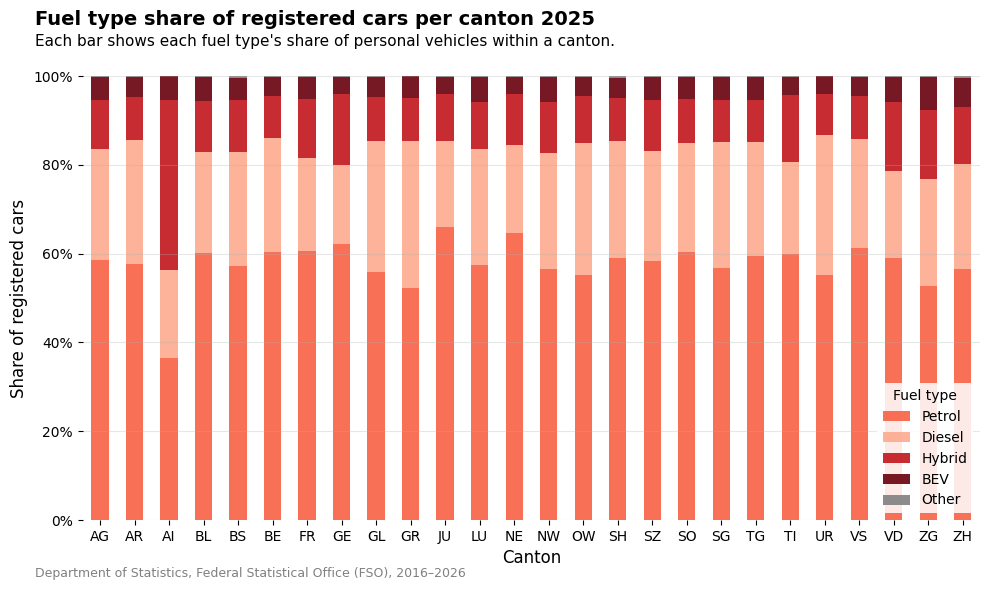

Saved: ..\docs\graphic_own\vis_b_bar_1.png


In [72]:
plot_order = ["Petrol", "Diesel", "Hybrid", "BEV", "Other"]
plot_df = bar_df[plot_order].sort_index(ascending=True)

pct_df = plot_df.div(plot_df.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=figure_size)
pct_df.plot( kind="bar", stacked=True, ax=ax,
    color=[colors[c] for c in plot_order],
    alpha=0.9,
)

for spine in ax.spines.values():
    spine.set_visible(False)

ax.grid(alpha=0.3, axis="y")
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x:.0f}%"))
ax.set_ylim(0, 100)
ax.set_xlabel("Canton", fontsize=12)
ax.set_ylabel("Share of registered cars", fontsize=12)

fig.text(s=f"Fuel type share of registered cars per canton {latest_year}", **title_cfg)
fig.text(s="Each bar shows each fuel type's share of personal vehicles within a canton.", **subtitle_cfg)

ax.set_xticklabels([canton_short.get(c, c) for c in pct_df.index], rotation=0)

ax.legend(title="Fuel type", loc="lower right",
          framealpha=0.85, edgecolor="none")

fig.text(**data_source_cfg)

plt.tight_layout()
plt.subplots_adjust(**cfg["plot_space"])

bar_path = output_dir / "vis_b_bar_1.png"
plt.savefig(bar_path, **saving_cfg)
plt.show()

print(f"Saved: {bar_path}")


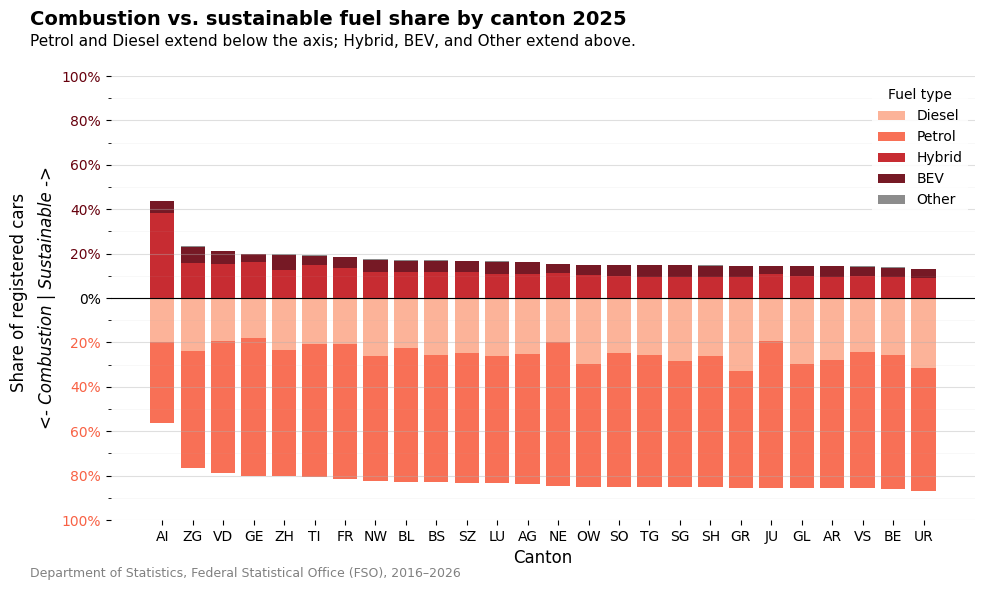

Saved: ..\docs\graphic_own\vis_b_bar_2.png


In [73]:
plot_order = ["Petrol", "Diesel", "Hybrid", "BEV", "Other"]


plot_df = bar_df[plot_order].copy()
pct_df = plot_df.div(plot_df.sum(axis=1), axis=0) * 100

# sort by sustainable % share descending
sustainable_pct = pct_df[["Hybrid", "BEV", "Other"]].sum(axis=1)
pct_df = pct_df.loc[sustainable_pct.sort_values(ascending=False).index]




below = ["Petrol", "Diesel"]
above = ["Hybrid", "BEV", "Other"]

fig, ax = plt.subplots(figsize=figure_size)

x = range(len(pct_df))
cantons = pct_df.index.tolist()

bottom_neg = pd.Series(0.0, index=pct_df.index)
for col in reversed(below):
    vals = -pct_df[col]
    ax.bar(x, vals, bottom=-bottom_neg, width=0.8,
           color=colors[col], alpha=0.9, label=col)
    bottom_neg += pct_df[col]

bottom_pos = pd.Series(0.0, index=pct_df.index)
for col in above:
    vals = pct_df[col]
    ax.bar(x, vals, bottom=bottom_pos, width=0.8,
           color=colors[col], alpha=0.9, label=col)
    bottom_pos += vals

ax.axhline(0, color="black", linewidth=0.8, zorder=3)
ax.set_ylim(-100, 100)

for spine in ax.spines.values():
    spine.set_visible(False)

ax.yaxis.set_major_locator(plt.MultipleLocator(20))
ax.yaxis.set_minor_locator(plt.MultipleLocator(10))
ax.grid(which="major", axis="y", alpha=0.4, linewidth=0.8)
ax.grid(which="minor", axis="y", alpha=0.15, linewidth=0.4)

ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{abs(x):.0f}%"))
ax.set_xlabel("Canton", fontsize=12)
fig.supylabel("Share of registered cars", fontsize=12)
ax.set_ylabel("<- Combustion | Sustainable ->", fontsize=12, style="italic")

ax.set_xticks(list(x))
ax.set_xticklabels([canton_short.get(c, c) for c in cantons], rotation=0)

fig.text(s=f"Combustion vs. sustainable fuel share by canton {latest_year}", **title_cfg)
fig.text(s="Petrol and Diesel extend below the axis; Hybrid, BEV, and Other extend above.", **subtitle_cfg)

ax.legend(title="Fuel type", loc="upper right", bbox_to_anchor=(1.0, 1.0),
          framealpha=0.85, edgecolor="none")

fig.text(**data_source_cfg)

plt.tight_layout()
plt.subplots_adjust(**cfg["plot_space"])

fig.canvas.draw()
for label in ax.get_yticklabels():
    val = label.get_position()[1]
    if val < 0:
        label.set_color(DIV_LABEL_COLORS["negative"])
    elif val > 0:
        label.set_color(DIV_LABEL_COLORS["positive"])
    else:
        label.set_color(DIV_LABEL_COLORS["zero"])

bar_path = output_dir / "vis_b_bar_2.png"
plt.savefig(bar_path, **saving_cfg)
plt.show()

print(f"Saved: {bar_path}")


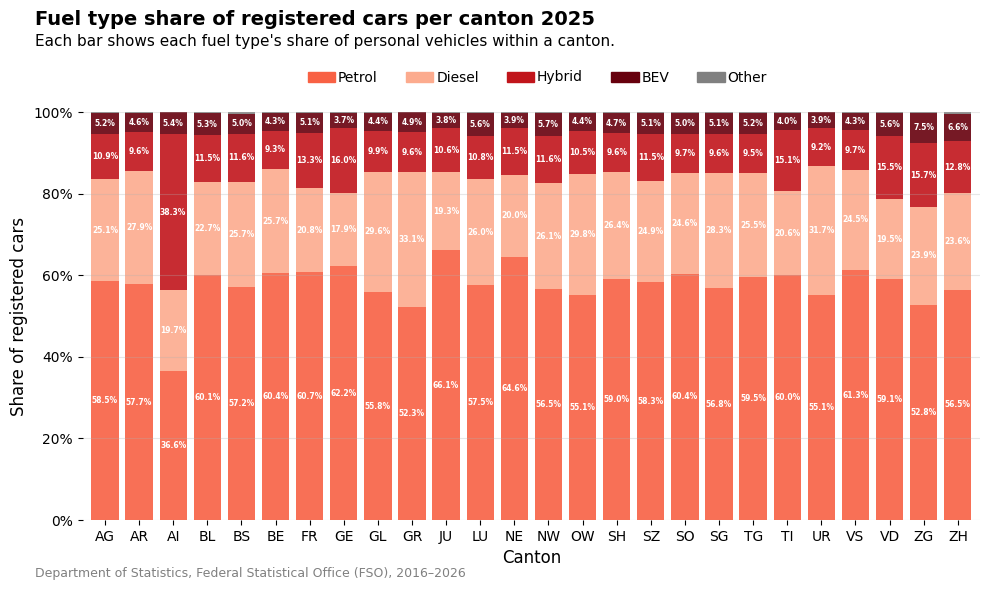

Saved: ..\docs\graphic_own\vis_b_bar_3.png


In [74]:
plot_order = ["Petrol", "Diesel", "Hybrid", "BEV", "Other"]
plot_df = bar_df[plot_order].sort_index(ascending=True)

pct_df = plot_df.div(plot_df.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=figure_size)
pct_df.plot(
    kind="bar",
    stacked=True,
    ax=ax,
    width=0.8,
    color=[colors[c] for c in plot_order],
    alpha=0.9,
    legend=False,
)

# Percentage labels inside segments — only if segment is wide enough to read
min_pct_to_label = 3
for bar_group in range(len(pct_df)):
    bottom = 0
    for col in plot_order:
        val = pct_df.iloc[bar_group][col]
        if val >= min_pct_to_label:
            ax.text(
                bar_group, bottom + val / 2,
                f"{val:.1f}%",
                ha="center", va="center",
                fontsize=5.5, color="white", fontweight="bold",
            )
        bottom += val

for spine in ax.spines.values():
    spine.set_visible(False)

ax.grid(alpha=0.3, axis="y")
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x:.0f}%"))
ax.set_ylim(0, 100)
ax.set_xlabel("Canton", fontsize=12)
ax.set_ylabel("Share of registered cars", fontsize=12)

fig.text(s=f"Fuel type share of registered cars per canton {latest_year}", **title_cfg)
fig.text(s="Each bar shows each fuel type's share of personal vehicles within a canton.", **subtitle_cfg)

ax.set_xticklabels([canton_short.get(c, c) for c in pct_df.index], rotation=0)

handles = [mpatches.Patch(color=colors[c], label=c) for c in plot_order]
fig.legend(
    handles=handles,
    loc="upper left",
    bbox_to_anchor=(0.3, 0.89),
    ncol=len(plot_order),
    frameon=False,
    fontsize=10,
    labelspacing=0.1, handletextpad=0.2,
)

fig.text(**data_source_cfg)

plt.tight_layout()
plt.subplots_adjust(top=0.8, bottom = cfg["plot_space"]["bottom"])

bar_path = output_dir / "vis_b_bar_3.png"
plt.savefig(bar_path, **saving_cfg)
plt.show()

print(f"Saved: {bar_path}")
